In [14]:
### it's important to choose how we get to have the labelled data from 25600 datapoints. Are they randomly selected?
### Are they from lhs? Are they evenly disributed?

import tensorflow as tf
import datetime, os
#hide tf logs 
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # or any {'0', '1', '2'} 
#0 (default) shows all, 1 to filter out INFO logs, 2 to additionally filter out WARNING logs, and 3 to additionally filter out ERROR logs
import scipy.optimize
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
import time
from pyDOE import lhs         #Latin Hypercube Sampling
import seaborn as sns 
import codecs, json

# generates same random numbers each time
np.random.seed(1234)
tf.random.set_seed(1234)

print("TensorFlow version: {}".format(tf.__version__))

TensorFlow version: 2.19.0


# *Data Prep*

Training and Testing data is prepared from the solution file

In [15]:
data = scipy.io.loadmat('Data/burgers_shock_mu_01_pi.mat')  	# Load data from file
x = data['x']                                   # 256 points between -1 and 1 [256x1]
t = data['t']                                   # 100 time points between 0 and 1 [100x1] 
usol = data['usol']                             # solution of 256x100 grid points

X, T = np.meshgrid(x, t)                        # makes 2 arrays X and T such that u(X[i],T[j])=usol[i][j] are a tuple

In [16]:
# np.shape(X.flatten()[None,:])

# *Test Data*

We prepare the test data to compare against the solution produced by the PINN.

In [17]:
''' X_u_test = [X[i],T[i]] [25600,2] for interpolation'''
X_u_test = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))

# Domain bounds
lb = X_u_test[0]  # [-1. 0.]
ub = X_u_test[-1] # [1.  0.99]

'''
   Fortran Style ('F') flatten,stacked column wise!
   u = [c1 
        c2
        .
        .
        cn]

   u =  [25600x1] 
'''
u = usol.flatten('F')[:,None] 

In [18]:
u.shape

(25600, 1)

# *Training Data*

The boundary conditions serve as the test data for the PINN and the collocation points are generated using **Latin Hypercube Sampling**

In [19]:
# def trainingdata(N_b, N_f):
def trainingdata(N_b, N_f, N_l):

    '''labelled data inside the domain'''
    
    X_all_labelled = np.hstack((X.flatten()[:,None], T.flatten()[:,None])) # all labelled 25600 X pairs
    u_all_labelled = usol.flatten('F')[:,None] # all 25600 labelled u's
    idx_l = np.random.choice(X_all_labelled.shape[0], N_l, replace=False) # the index of laballed data
    X_labelled = X_all_labelled[idx_l, :] # choose (x,t) pairs from the set X_all_labelled with indices 'idx_l'
    u_labelled = u_all_labelled[idx_l, :] # choose u's from the set u_all_labelled with indices 'idx_l'

    '''the data that should meet the Boundary Conditions'''

    #Initial Condition -1 =< x =<1 and t = 0  
    leftedge_x = np.hstack((X[0,:][:,None], T[0,:][:,None])) #L1
    leftedge_u = usol[:,0][:,None]

    #Boundary Condition x = -1 and 0 =< t =<1
    bottomedge_x = np.hstack((X[:,0][:,None], T[:,0][:,None])) #L2
    bottomedge_u = usol[-1,:][:,None] # bottomedge_u = usol[0,:][:,None]

    #Boundary Condition x = 1 and 0 =< t =<1
    topedge_x = np.hstack((X[:,-1][:,None], T[:,0][:,None])) #L3
    topedge_u = usol[0,:][:,None] # topedge_u = usol[-1,:][:,None]

    all_X_u_train = np.vstack([leftedge_x, bottomedge_x, topedge_x]) # all_X_u_train [456,2] (456 = 256(L1)+100(L2)+100(L3))
    all_u_train = np.vstack([leftedge_u, bottomedge_u, topedge_u])   #and the corresponding u [456x1]

    #choose random N_u points for training
    idx_b = np.random.choice(all_X_u_train.shape[0], N_b, replace=False) # index of boundary points

    X_u_train = all_X_u_train[idx_b, :] #choose indices from  set 'idx_b' (x,t)
    u_train = all_u_train[idx_b,:]      #choose corresponding u

    '''Residual PDE Points'''

    # Latin Hypercube sampling for collocation points 
    # N_f sets of tuples(x,t)
    X_f_train = lb + (ub-lb)*lhs(2, N_f) 
    X_f_train = np.vstack((X_f_train, X_u_train)) # append training points to collocation points 

#     return X_f_train, X_u_train, u_train 
    return X_f_train, X_u_train, u_train, X_labelled, u_labelled


# **PINN**

Generate a **PINN** of L hidden layers, each with n neurons. 

Initialization: ***Xavier***

Activation: *tanh (x)*

In [20]:
class Sequentialmodel(tf.Module): 
    def __init__(self, layers, name=None):
       
        self.W = []  #Weights and biases
        self.parameters = 0 #total number of parameters
        self.iteration = 0
        self.losss_history = np.array([])
        self.error_history = np.array([])
        self.w_history = np.array([])
####    self.lambda1_history = np.array([])
####    self.lambda2_history = np.array([])
####    self.lambda1 = tf.Variable([-5.0], dtype='float64', trainable = True)
####    self.parameters += 1
        
        for i in range(len(layers)-1):
            
            input_dim = layers[i]
            output_dim = layers[i+1]
            
            #Xavier standard deviation 
            std_dv = np.sqrt((2.0/(input_dim + output_dim)))

            #weights = normal distribution * Xavier standard deviation + 0
            w = tf.random.normal([input_dim, output_dim], dtype = 'float64') * std_dv                       
            w = tf.Variable(w, trainable=True, name = 'w' + str(i+1))
            b = tf.Variable(tf.cast(tf.zeros([output_dim]), dtype = 'float64'), trainable = True, name = 'b' + str(i+1))                    
            self.W.append(w)
            self.W.append(b)            
            self.parameters +=  input_dim * output_dim + output_dim
    
    def evaluate(self, x):
        
        x = (x-lb)/(ub-lb)        
        a = x        
        for i in range(len(layers)-2):            
            z = tf.add(tf.matmul(a, self.W[2*i]), self.W[2*i+1])
            a = tf.nn.tanh(z)            
        a = tf.add(tf.matmul(a, self.W[-2]), self.W[-1]) # For regression, no activation to last layer
        return a
    
    def get_weights(self):

        parameters_1d = []  # [.... W_i,b_i.....  ] 1d array
        
        for i in range (len(layers)-1):
            
            w_1d = tf.reshape(self.W[2*i],[-1])   #flatten weights 
            b_1d = tf.reshape(self.W[2*i+1],[-1]) #flatten biases
            
            parameters_1d = tf.concat([parameters_1d, w_1d], 0) #concat weights 
            parameters_1d = tf.concat([parameters_1d, b_1d], 0) #concat biases
        
        return parameters_1d
        
    def set_weights(self,parameters):
                
        for i in range (len(layers)-1):

            shape_w = tf.shape(self.W[2*i]).numpy() # shape of the weight tensor
            size_w = tf.size(self.W[2*i]).numpy() #size of the weight tensor 
            
            shape_b = tf.shape(self.W[2*i+1]).numpy() # shape of the bias tensor
            size_b = tf.size(self.W[2*i+1]).numpy() #size of the bias tensor 
                        
            pick_w = parameters[0:size_w] #pick the weights 
            self.W[2*i].assign(tf.reshape(pick_w,shape_w)) # assign  
            parameters = np.delete(parameters,np.arange(size_w),0) #delete 
            
            pick_b = parameters[0:size_b] #pick the biases 
            self.W[2*i+1].assign(tf.reshape(pick_b,shape_b)) # assign 
            parameters = np.delete(parameters,np.arange(size_b),0) #delete 
    
    def loss_labelled(self, x, y):
        loss_l = tf.reduce_mean(tf.square(y-self.evaluate(x)))
        return loss_l
            
    def loss_BC(self, x, y):
        loss_u = tf.reduce_mean(tf.square(y-self.evaluate(x)))        
        return loss_u

    def loss_PDE(self, x_to_train_f):
    
        g = tf.Variable(x_to_train_f, dtype = 'float64', trainable = False)
    
        lambda2 = 0.01/np.pi

        x_f = g[:,0:1]
        t_f = g[:,1:2]

        with tf.GradientTape(persistent=True) as tape:

            tape.watch(x_f)
            tape.watch(t_f)

            g = tf.stack([x_f[:,0], t_f[:,0]], axis=1)   
            z = self.evaluate(g)
            u_x = tape.gradient(z, x_f)

        u_t = tape.gradient(z, t_f)    
        u_xx = tape.gradient(u_x, x_f)

        del tape

        f = u_t + (self.evaluate(g))*(u_x) - lambda2*u_xx #### why not use z?

        loss_f = tf.reduce_mean(tf.square(f))

        return loss_f
    
    def loss(self, x, y, g, a, b):
        loss_l = self.loss_labelled(a, b)
        loss_u = self.loss_BC(x, y)
        loss_f = self.loss_PDE(g)

        loss = loss_u + loss_f + loss_l
        return loss, loss_u, loss_f, loss_l
    
    def optimizerfunc(self, parameters):
        
        self.set_weights(parameters)
       
        with tf.GradientTape() as tape:
            tape.watch(self.trainable_variables)
            loss_val, loss_u, loss_f, loss_l = self.loss(X_u_train, u_train, X_f_train, X_labelled, u_labelled)  
        grads = tape.gradient(loss_val, self.trainable_variables)      
        del tape
        
        grads_1d = [ ] #flatten grads 
        
        for i in range (len(layers)-1):

            grads_w_1d = tf.reshape(grads[2*i], [-1]) #flatten weights 
            grads_b_1d = tf.reshape(grads[2*i+1], [-1]) #flatten biases

            grads_1d = tf.concat([grads_1d, grads_w_1d], 0) #concat grad_weights 
            grads_1d = tf.concat([grads_1d, grads_b_1d], 0) #concat grad_biases

        return loss_val.numpy(), grads_1d.numpy()
    
    def optimizer_callback(self, parameters):
        self.iteration += 1
        
        loss_value, loss_u, loss_f, loss_l = self.loss(X_u_train, u_train, X_f_train, X_labelled, u_labelled)
        
        u_pred = self.evaluate(X_u_test)
        error = np.linalg.norm((u-u_pred),2)/np.linalg.norm(u,2)
        self.error_history = np.append(self.error_history, error)
        
        self.w_history = np.append(self.w_history, self.W[0][0][0]) ### putting the probe on a single weight amongst all.
        
        self.losss_history = np.append(self.losss_history, loss_value.numpy())
        print('iteration', self.iteration, 'error:', error, 'loss_value:', loss_value.numpy())

# *Solution Plot*

In [21]:
def solutionplot(u_pred,X_u_train,u_train):
    
    fig, ax = plt.subplots()
    ax.axis('off')

    gs0 = gridspec.GridSpec(1, 2)
    gs0.update(top=1-0.06, bottom=1-1/3, left=0.15, right=0.85, wspace=0)
    ax = plt.subplot(gs0[:, :])

    h = ax.imshow(u_pred, interpolation='nearest', cmap='rainbow', 
                extent=[T.min(), T.max(), X.min(), X.max()], 
                origin='lower', aspect='auto')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(h, cax=cax)
    
    ax.plot(X_u_train[:,1], X_u_train[:,0], 'kx', label = 'Data (%d points)' % (u_train.shape[0]), markersize = 4, clip_on = False)

    line = np.linspace(x.min(), x.max(), 2)[:,None]
    ax.plot(t[25]*np.ones((2,1)), line, 'w-', linewidth = 1)
    ax.plot(t[50]*np.ones((2,1)), line, 'w-', linewidth = 1)
    ax.plot(t[75]*np.ones((2,1)), line, 'w-', linewidth = 1)    

    ax.set_xlabel('$t$')
    ax.set_ylabel('$x$')
    ax.legend(frameon=False, loc = 'best')
    ax.set_title('$u(x,t)$', fontsize = 10)
    
    ''' 
    Slices of the solution at points t = 0.25, t = 0.50 and t = 0.75
    '''
    
    ####### Row 1: u(t,x) slices ##################
    gs1 = gridspec.GridSpec(1, 3)
    gs1.update(top=1-1/3, bottom=0, left=0.1, right=0.9, wspace=0.5)

    ax = plt.subplot(gs1[0, 0])
    ax.plot(x,usol.T[25,:], 'b-', linewidth = 2, label = 'Exact')       
    ax.plot(x,u_pred.T[25,:], 'r--', linewidth = 2, label = 'Prediction')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$u(x,t)$')    
    ax.set_title('$t = 0.25s$', fontsize = 10)
    ax.axis('square')
    ax.set_xlim([-1.1,1.1])
    ax.set_ylim([-1.1,1.1])

    ax = plt.subplot(gs1[0, 1])
    ax.plot(x,usol.T[50,:], 'b-', linewidth = 2, label = 'Exact')       
    ax.plot(x,u_pred.T[50,:], 'r--', linewidth = 2, label = 'Prediction')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$u(x,t)$')
    ax.axis('square')
    ax.set_xlim([-1.1,1.1])
    ax.set_ylim([-1.1,1.1])
    ax.set_title('$t = 0.50s$', fontsize = 10)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=5, frameon=False)

    ax = plt.subplot(gs1[0, 2])
    ax.plot(x,usol.T[75,:], 'b-', linewidth = 2, label = 'Exact')       
    ax.plot(x,u_pred.T[75,:], 'r--', linewidth = 2, label = 'Prediction')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$u(x,t)$')
    ax.axis('square')
    ax.set_xlim([-1.1,1.1])
    ax.set_ylim([-1.1,1.1])    
    ax.set_title('$t = 0.75s$', fontsize = 10)
    
    plt.savefig('Burgers.png',dpi = 500)   

# *Model Training and Testing*

A function '**model**' is defined to generate a NN as per the input set of hyperparameters, which is then trained and tested. The L2 Norm of the solution error is returned as a comparison metric

In [ ]:
# thesis specifications: L-BFGS, N_l=10000, 'maxiter'=8000, 
# layers = [2,20,20,20,20,1]

# original: L-BFGS, N_l=10000, 'maxiter'=2000, 
# layers = [2,20,20,20,20,20,20,20,20,1]

N_u = 100 #Total number of training boundary points
N_f = 10000 #Total number of training PDE residual points 
N_l = 10000 #Total number of training labelled points 

# Training data
X_f_train, X_u_train, u_train, X_labelled, u_labelled = trainingdata(N_u, N_f, N_l)

layers = np.array([2,20,20,20,20,1]) #8 hidden layers

PINN = Sequentialmodel(layers)

init_params = PINN.get_weights().numpy()

start_time = time.time() 




# train the model with Scipy L-BFGS optimizer
results = scipy.optimize.minimize(fun = PINN.optimizerfunc, 
                                  x0 = init_params, 
                                  args=(), 
                                  method='L-BFGS-B', 
                                  jac= True,        # If jac is True, fun is assumed to return the gradient along with the objective function
                                  callback = PINN.optimizer_callback, 
                                  options = {'disp': None,
                                            'maxcor': 200, 
                                            'ftol': 1 * np.finfo(float).eps,  #The iteration stops when (f^k - f^{k+1})/max{|f^k|,|f^{k+1}|,1} <= ftol
                                            'gtol': 5e-8, 
                                            'maxfun':  50000, 
                                            'maxiter': 8000,
                                            'iprint': -1,   #print update every 50 iterations
                                            'maxls': 50})

elapsed = time.time() - start_time                
print('Training time: %.2f' % (elapsed/60.0))

print(results)

PINN.set_weights(results.x)

''' Model Accuracy ''' 
u_pred = PINN.evaluate(X_u_test)

error_vec = np.linalg.norm((u-u_pred),2)/np.linalg.norm(u,2)        # Relative L2 Norm of the error (Vector)
print('Test Error: %.5f'  % (error_vec))

u_pred = np.reshape(u_pred, (256,100), order='F')                        # Fortran Style ,stacked column wise!

''' Solution Plot '''
solutionplot(u_pred, X_u_train, u_train)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_10928\2796741124.py:26: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  results = scipy.optimize.minimize(fun = PINN.optimizerfunc,


iteration 1 error: 0.8999172122209401 loss_value: 0.5557381713152749
iteration 2 error: 0.8925378655792806 loss_value: 0.5461854212444681
iteration 3 error: 0.8817050889034455 loss_value: 0.5384920047541499
iteration 4 error: 0.8638871612184448 loss_value: 0.5284846080292234
iteration 5 error: 0.8449981478498565 loss_value: 0.5212091926883832
iteration 6 error: 0.8437410904052721 loss_value: 0.5206640110988754
iteration 7 error: 0.8446188983778056 loss_value: 0.5205950039877482
iteration 8 error: 0.8451750830022899 loss_value: 0.520506996830477
iteration 9 error: 0.846424290523144 loss_value: 0.5201992615634092
iteration 10 error: 0.8475888759539226 loss_value: 0.5196538775595428
iteration 11 error: 0.847995004818594 loss_value: 0.5187547744550959
iteration 12 error: 0.846446396260592 loss_value: 0.5176666356327886
iteration 13 error: 0.8433132662375092 loss_value: 0.5168752274512568
iteration 14 error: 0.8417286439962847 loss_value: 0.5166707043929253
iteration 15 error: 0.84055962988

# Plot of collocation points

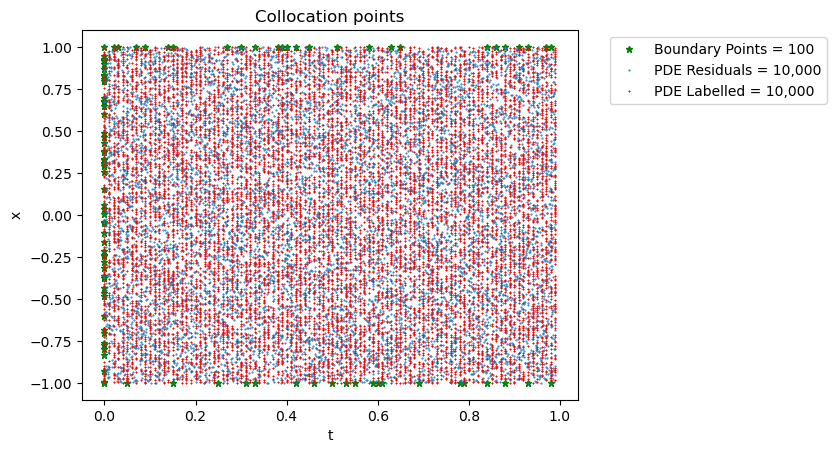

In [ ]:
N_u = 100 #Total number of data points for 'u'
N_f = 10000 #Total number of collocation points 
N_l = 10000 #Total number of training labelled points 

# Training data
X_f_train, X_u_train, u_train , X_labelled, u_labelled = trainingdata(N_u, N_f, N_l)

fig,ax = plt.subplots()

plt.plot(X_u_train[:,1], X_u_train[:,0], '*', color = 'green', markersize = 5, label = 'Boundary Points = 100')
plt.plot(X_f_train[:,1], X_f_train[:,0], 'o', markersize = 0.5, label = 'PDE Residuals = 10,000')
plt.plot(X_labelled[:,1], X_labelled[:,0], 'P', color = 'red', markersize = 0.5, label = 'PDE Labelled = 10,000')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Collocation points')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

fig.savefig('collocation_points_Burgers.png', dpi = 500, bbox_inches='tight')

In [ ]:
X_labelled

array([[ 0.25490196,  0.81      ],
       [-0.01176471,  0.32      ],
       [-0.85882353,  0.85      ],
       ...,
       [ 0.41960784,  0.82      ],
       [ 0.41960784,  0.61      ],
       [-0.01176471,  0.19      ]])

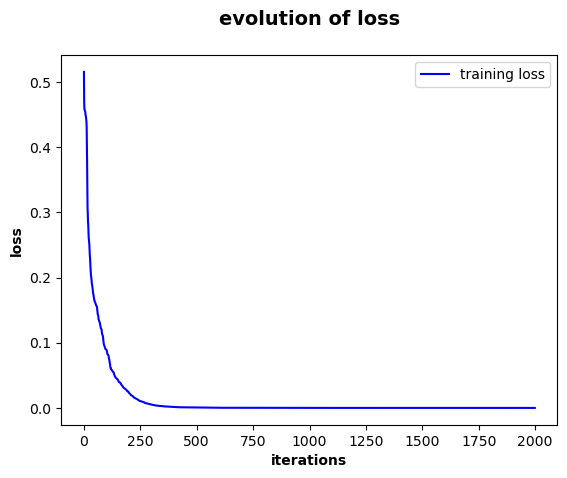

In [ ]:
# PINN.losss_history
fig, ax = plt.subplots()  
ax.plot(PINN.losss_history, 'b')
# ax.set_ylim(0, 5)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('loss', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('evolution of loss\n', fontsize = 14, fontweight ='bold')
plt.savefig('loss.png')
plt.legend(['training loss'])
plt.show()

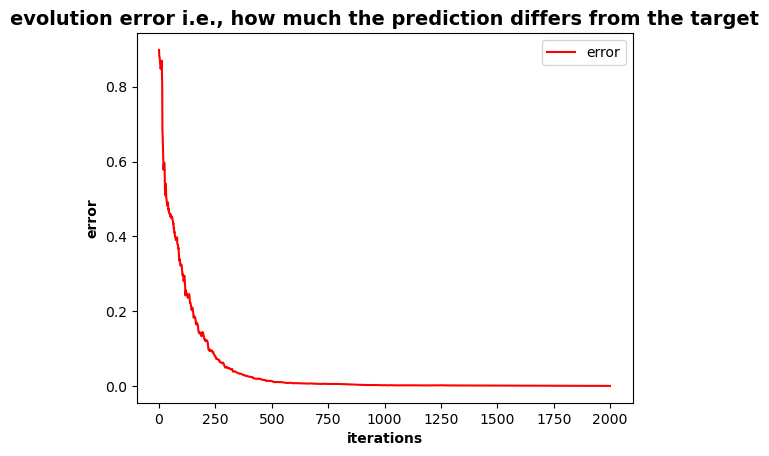

In [ ]:
fig, ax = plt.subplots()  
ax.plot(PINN.error_history, 'r')
# ax.set_xlim(5, 0)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('error', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('evolution error i.e., how much the prediction differs from the target', fontsize = 14, fontweight ='bold')
plt.savefig('error history.png')
plt.legend(['error'])
plt.show()

In [ ]:
len(PINN.trainable_variables)

18

In [ ]:
PINN.W[0][0][0].numpy()

-0.045108467408138515

In [ ]:
PINN.W[0].numpy()

array([[-0.04510847,  0.19087183, -0.77457791,  0.98959984,  0.35829803,
         0.17665427,  1.03057128, -0.4973624 , -0.14794518,  0.25606873,
         0.21978643, -0.32616143, -1.46499785,  0.8827954 ,  1.09817005,
         0.13300189,  0.47904778, -0.78961712,  0.46354317, -0.7846877 ],
       [ 0.36042517,  0.36562745, -0.20644292,  0.72492228, -0.56204251,
        -0.60069665, -1.12751802,  0.38131929, -0.38867084, -0.24054259,
        -0.03889014, -0.2648479 ,  0.26854458, -0.31110346, -0.22822837,
         0.60606917, -0.31424035,  0.35351206, -0.00967595, -0.24207183]])

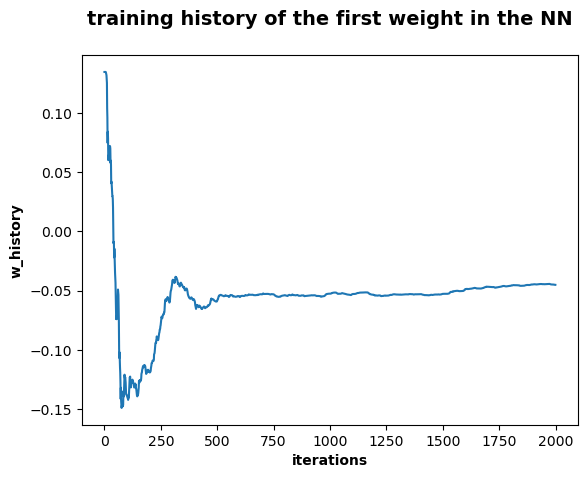

In [ ]:
fig, ax = plt.subplots()  
ax.plot(PINN.w_history)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('w_history', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('training history of the first weight in the NN\n', fontsize = 14, fontweight ='bold')
plt.savefig('w0.png')
plt.show()